# SIH26168 Colab Training — AVNetLite on IO-VNBD
Target 95% accuracy (<5% drift). Run all cells in order. T4 GPU recommended.

In [6]:
!git clone https://github.com/Himanshu121865/sih26168.git
%cd sih26168
!pip install torch --index-url https://download.pytorch.org/whl/cu121 -q
!pip install pandas scipy onnx onnxruntime onnxscript loguru matplotlib scikit-learn -q
import torch; print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

Cloning into 'sih26168'...
remote: Enumerating objects: 431, done.
remote: Counting objects: 100% (431/431), done.
remote: Compressing objects: 100% (282/282), done.
remote: Total 431 (delta 177), reused 334 (delta 82), pack-reused 0 (from 0)
Receiving objects: 100% (431/431), 32.57 MiB | 13.99 MiB/s, done.
Resolving deltas: 100% (177/177), done.
Updating files: 100% (74/74), done.
/content/sih26168/sih26168
True Tesla T4


In [7]:
!python python/download_iovnbd.py --subset Sync
!ls -lh data/iovnbd/*.zip
# FULL Categorised 72 seqs (~1M windows, ~5GB npy, streaming via mmap) — ~7 mins preprocess, 35 mins train 50ep
!PYTHONPATH=. python python/preprocess.py --subset full --window 200 --stride 10 --hz 100
!ls -lh data/processed/ && cat python/scaler.json | head -20

[dl] https://media.githubusercontent.com/media/onyekpeu/IO-VNBD/master/Synchronised%20V%20abd%20S%20datasets.zip -> data/iovnbd/Synchronised V abd S datasets.zip (203.6 MB)
  99.8%
[done] data/iovnbd/Synchronised V abd S datasets.zip 203606286 bytes
[unzip] data/iovnbd/Synchronised V abd S datasets.zip -> data/iovnbd/
[unzip] done [PosixPath('data/iovnbd/Synchronised V abd S datasets/Uncategorised IOVNB Dataset'), PosixPath('data/iovnbd/Synchronised V abd S datasets/Categorised IOVNB Dataset')]
[ok] download_iovnbd done
-rw-r--r-- 1 root root 195M Sep  4 19:11 'data/iovnbd/Synchronised V abd S datasets.zip'
[preprocess] 72 S files, window=200 stride=10 hz=100 resume=False
[split] train files 57 val files 15 (by trajectory, seed 26168)
[ok] M (Driver B)/S-M.csv: T=105974->617597 windows=61740 stationary=1600 median_dt=51.0ms
[ok] S1/S-S1.csv: T=51746->517450 windows=51726 stationary=4859 median_dt=100.0ms
[ok] S2/S-S2.csv: T=93876->920111 windows=91992 stationary=11313 median_dt=100.0ms

In [8]:
# Retrain with P0 fixes: ZUPT (5.7% stationary), random-yaw + NLL — 15ep is enough for full 822k
!PYTHONPATH=. python python/train_avnet.py --epochs 15 --batch 256 --lr 1e-3 --device cuda --augment-yaw --augment-bike --lambda-nll 0.1
!ls -lh experiments/checkpoints/

[train] device cuda epochs 15 batch 256 lr 0.001 augment_yaw=True augment_bike=True lambda_nll=0.1
[dataset] npy mode data/processed/train_windows.npy
[dataset] npy mode data/processed/val_windows.npy
[data] train 822928 val 178369
[model] params 460,136
[epoch 1/15] train loss 1.7893 (mse 1.8051) val MSE 1.8136 lr 1.00e-03 90.3s
  [save] experiments/checkpoints/model_avnet_stage1.p best 1.8136
[epoch 2/15] train loss 1.4214 (mse 1.4210) val MSE 2.0990 lr 1.00e-03 54.6s
[epoch 3/15] train loss 1.3439 (mse 1.3411) val MSE 1.8392 lr 1.00e-03 55.7s
[epoch 4/15] train loss 1.2969 (mse 1.2925) val MSE 1.9588 lr 1.00e-03 54.5s
[epoch 5/15] train loss 1.2624 (mse 1.2566) val MSE 1.9922 lr 1.00e-03 54.8s
[epoch 6/15] train loss 1.2340 (mse 1.2278) val MSE 1.7701 lr 1.00e-03 55.0s
  [save] experiments/checkpoints/model_avnet_stage1.p best 1.7701
[epoch 7/15] train loss 1.2198 (mse 1.2116) val MSE 1.7726 lr 1.00e-03 54.7s
[epoch 8/15] train loss 1.2013 (mse 1.1933) val MSE 1.8374 lr 1.00e-03 54.

[dataset] npy mode data/processed/val_windows.npy
[mse] val MSE 1.7701 RMSE 1.3305 m/s
/content/sih26168/sih26168/python/eval_drift.py:99: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  xb = torch.from_numpy(X_seg[i:i+64])
[eval] segment 600 windows (60s) total_dist 99.8m
  naive final 16.4m drift 16.4%
  AI final 77.5m drift 77.6%
  AI+map final 46.5m drift 46.6%
[plot] saved reports/drift_plot.png


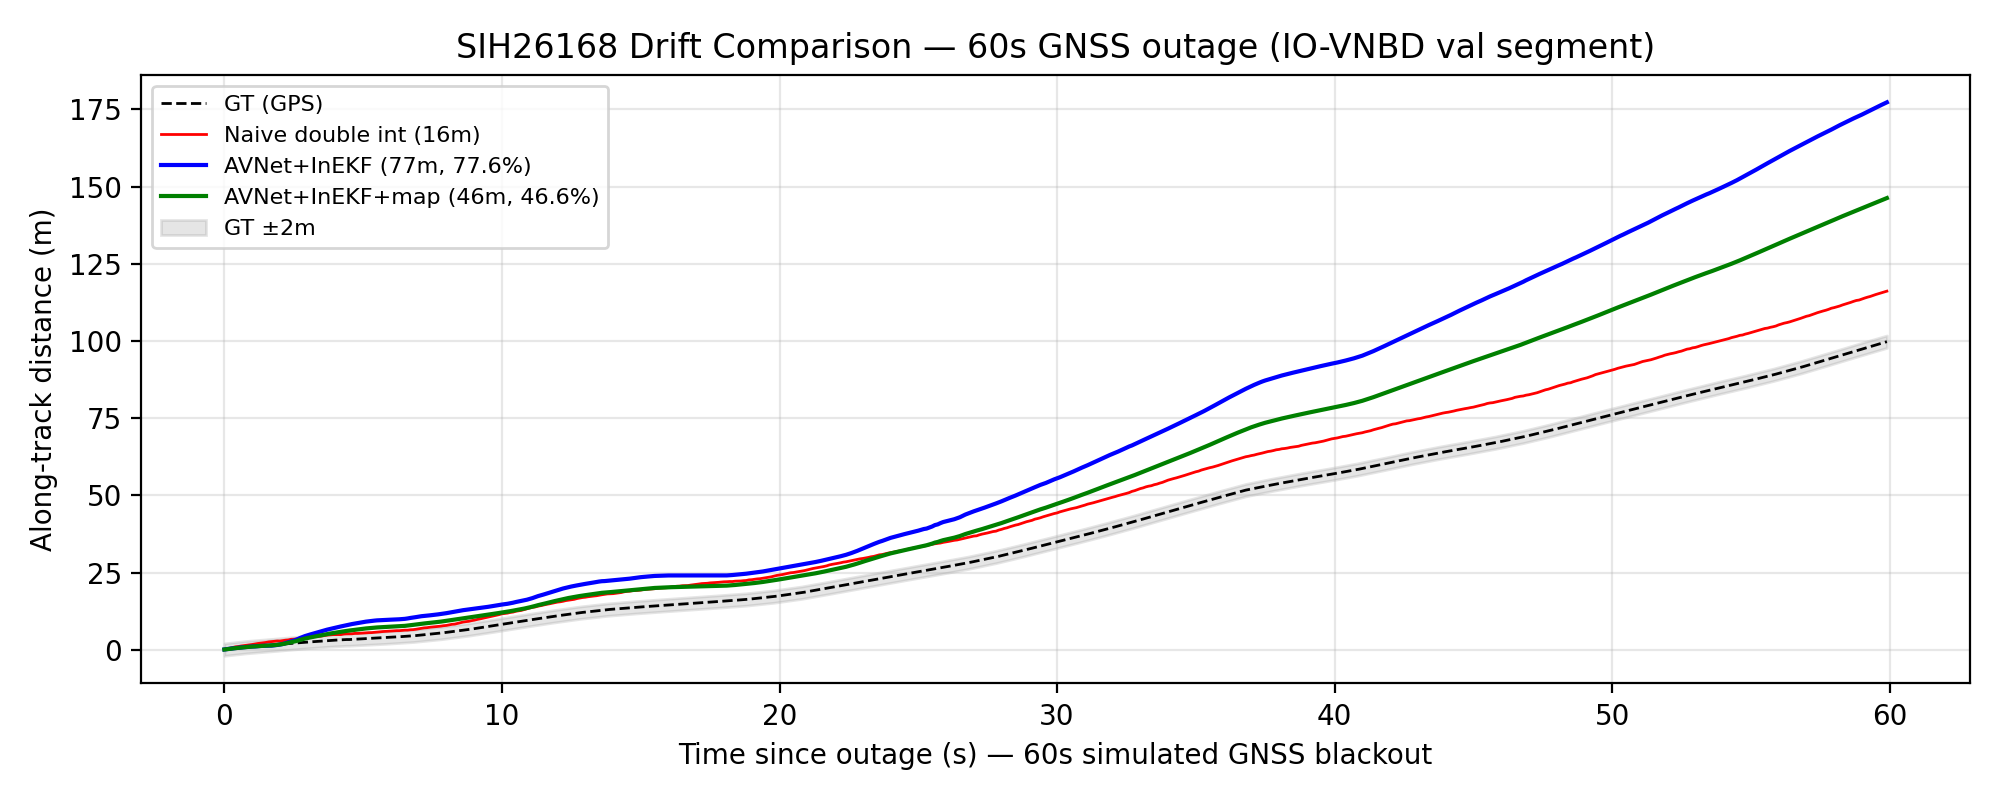

In [9]:
!PYTHONPATH=. python python/eval_drift.py --model experiments/checkpoints/model_avnet_stage1.p --plot reports/drift_plot.png
from IPython.display import Image; Image("reports/drift_plot.png")

In [10]:
!PYTHONPATH=. python python/export_tflite.py --model experiments/checkpoints/model_avnet_stage1.p --out model.tflite --onnx model.onnx
!ls -lh model.* scaler.json
!zip -r screening.zip model.tflite scaler.json reports/drift_plot.png python/scaler.json
!ls -lh screening.zip

[load] experiments/checkpoints/model_avnet_stage1.p
[model] 460,136 params, est FP32 1.84 MB FP16 0.92 MB
/content/sih26168/sih26168/python/export_tflite.py:21: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0904 19:29:28.127000 12961 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
[torch.onnx] Obtain model graph for `AVNetLite([...]` with `torch.export.export(..., strict=False)`.

[test-lean] PASS — bike φ=30°: v_lat=2.500 m/s (expected 2.500), R_scale=2.047
[test-lean] PASS — car fallback: v_lat=0, R_scale=1.0
[harness] segment 600 windows (60s) total_dist 160.2m mode=car q_acc=30.0
  naive  final   349.3m   218.1%
  avnet  final    17.9m    11.2%
  inekf  final     3.5m     2.2%
  mean |v_pred-v_gt| 0.964 m/s | mean σ_v 3.646 | mean φ 38.4° | mean p_bike 0.00 | P_trace 2.89e+03 | zupt 72/600
[csv] appended reports/inekf_vs_avnet.csv
[dataset] npy mode data/processed/val_windows.npy
[mse] val MSE 1.7701 RMSE 1.3305 m/s
/content/sih26168/sih26168/python/eval_drift.py:177: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils

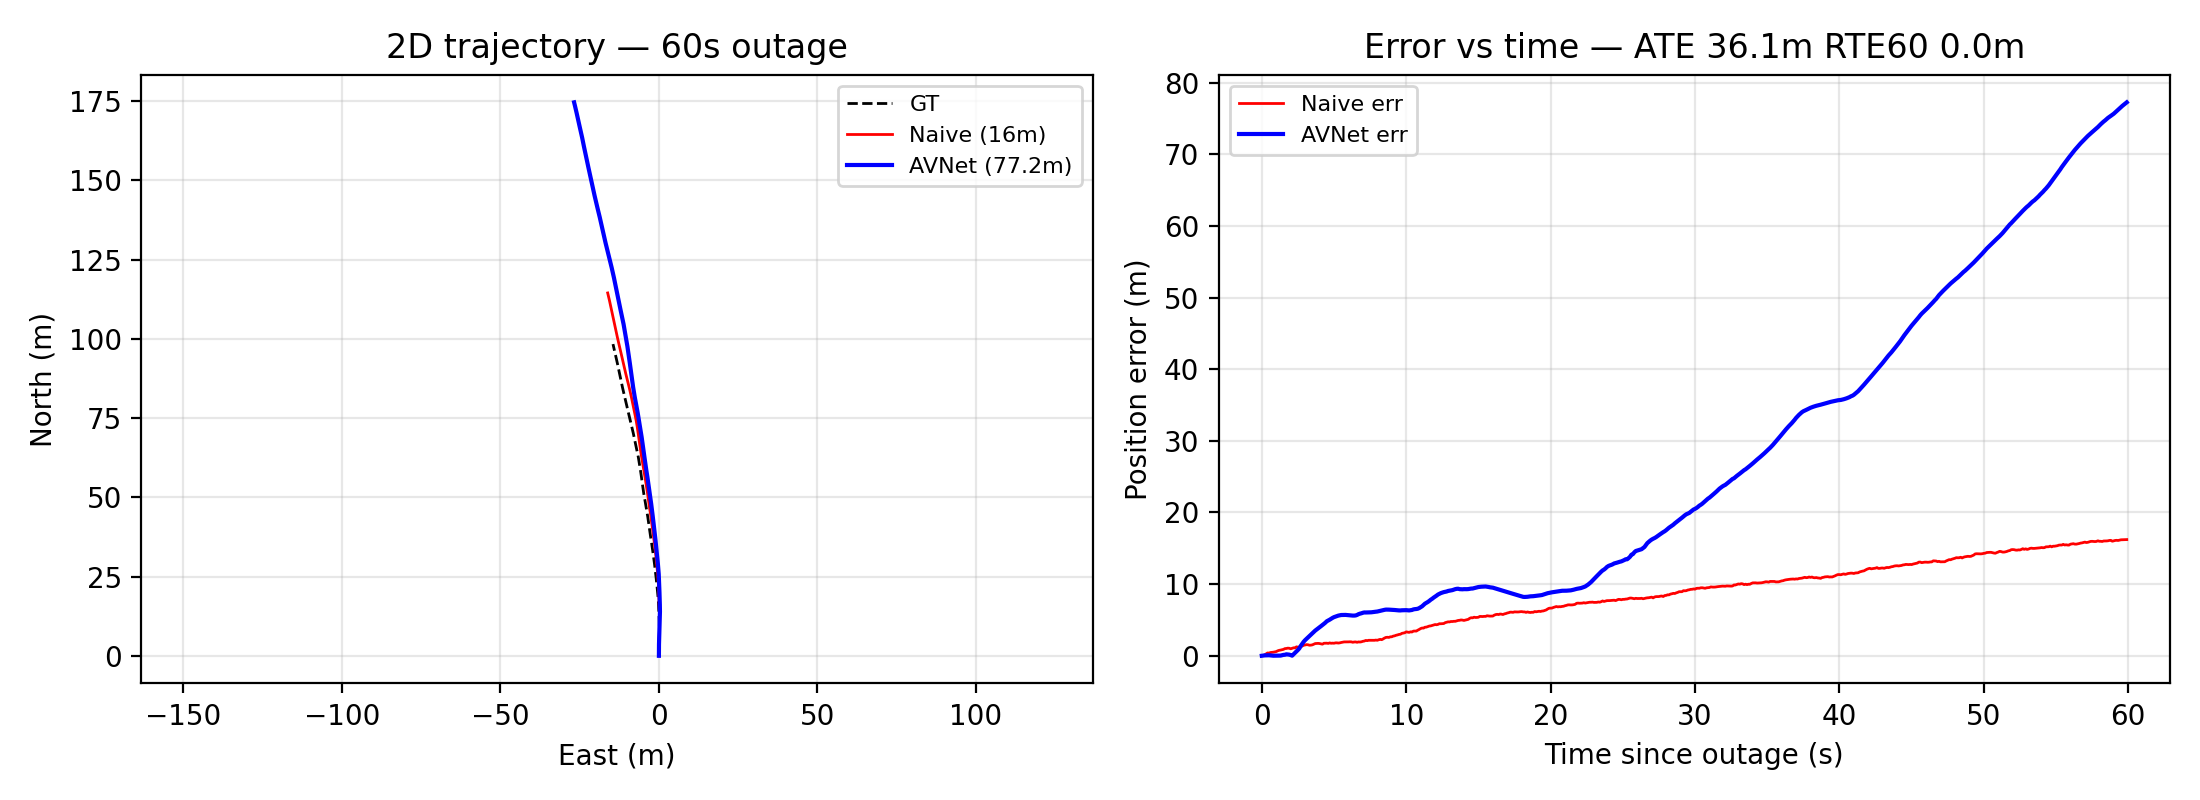

In [11]:
# F1-F7 verification (added 2026-09-04)
!PYTHONPATH=. python python/inekf_harness.py --test-lean
!PYTHONPATH=. python python/inekf_harness.py --model experiments/checkpoints/model_avnet_stage1.p --windows 600 --start 2000 --lean-mode car --q-acc 30.0
!PYTHONPATH=. python python/eval_drift.py --mode 2d --model experiments/checkpoints/model_avnet_stage1.p --plot reports/drift_2d.png
from IPython.display import Image; Image("reports/drift_2d.png")
